In [1]:


!pip install librosa -q



In [2]:
## Cell 2: Import Libraries

import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_style("whitegrid")

print("Libraries loaded successfully")


Libraries loaded successfully


In [3]:
## Cell 3: Define Dataset Path



DATASET_PATH = "/kaggle/input/datasets/mathias256/breath/BREATH"

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Total audio files found: {len(audio_files)}")


Total audio files found: 520


In [4]:

## Cell 4: Feature Extraction Function

def extract_features(file_path):

    y, sr = librosa.load(file_path, sr=None)

    # RMS Energy
    rms = librosa.feature.rms(y=y)

    # Spectral Centroid
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    # MFCCs
    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    features = {
        "file": os.path.basename(file_path),
        "rms_mean": np.mean(rms),
        "spectral_centroid_mean": np.mean(centroid)
    }

    for i in range(13):
        features[f"mfcc_{i+1}"] = np.mean(mfccs[i])

    return features


In [5]:
## Cell 5: Extract Features from All Files


all_features = []

for file in tqdm(audio_files):
    try:
        all_features.append(extract_features(file))
    except Exception as e:
        print(f"Error: {file}")
        print(e)

feature_df = pd.DataFrame(all_features)

print(feature_df.shape)

feature_df.head()


## Cell 6: Save Feature Dataset

feature_df.to_csv(
    "breathing_audio_features.csv",
    index=False
)

print("Feature file saved.")


100%|██████████| 520/520 [00:42<00:00, 12.37it/s]

(520, 16)
Feature file saved.


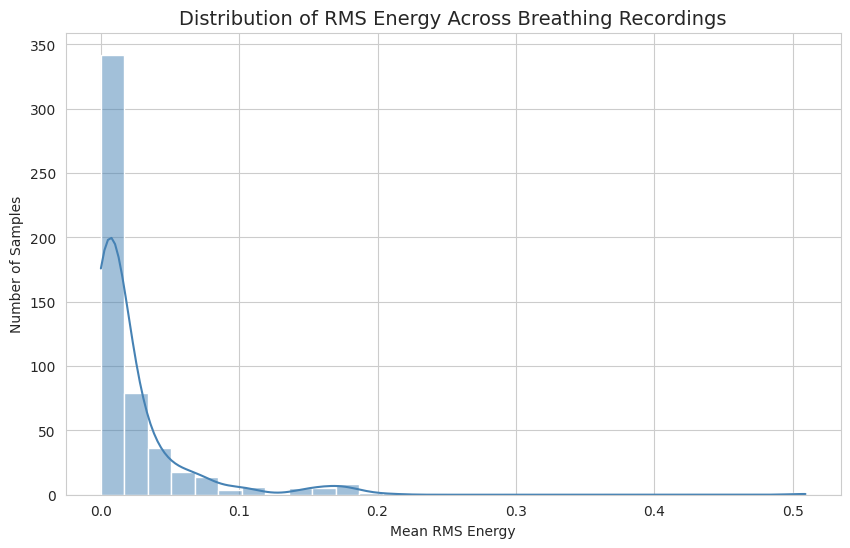

In [6]:
## Cell 7: RMS Energy Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    feature_df["rms_mean"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of RMS Energy Across Breathing Recordings",
    fontsize=14
)

plt.xlabel("Mean RMS Energy")
plt.ylabel("Number of Samples")

plt.show()


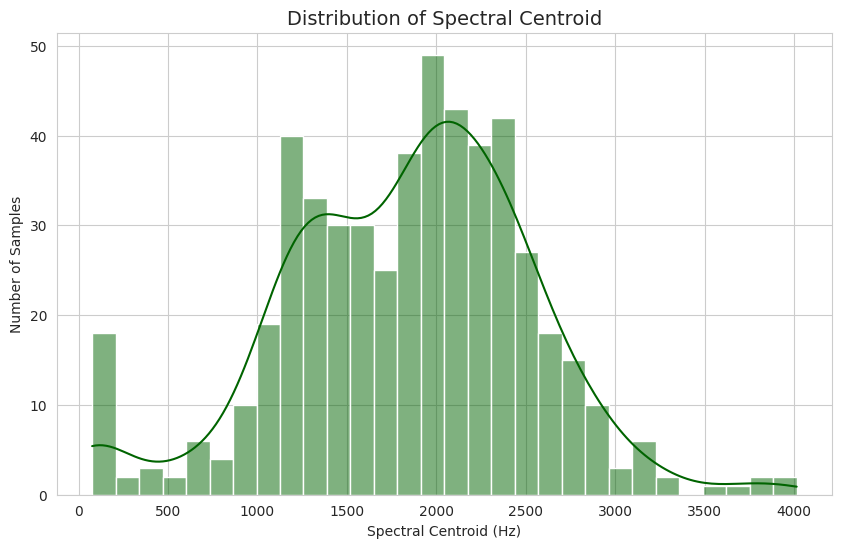

In [7]:
## Cell 8: Spectral Centroid Distribution


plt.figure(figsize=(10,6))

sns.histplot(
    feature_df["spectral_centroid_mean"],
    bins=30,
    kde=True,
    color="darkgreen"
)

plt.title(
    "Distribution of Spectral Centroid",
    fontsize=14
)

plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Number of Samples")

plt.show()


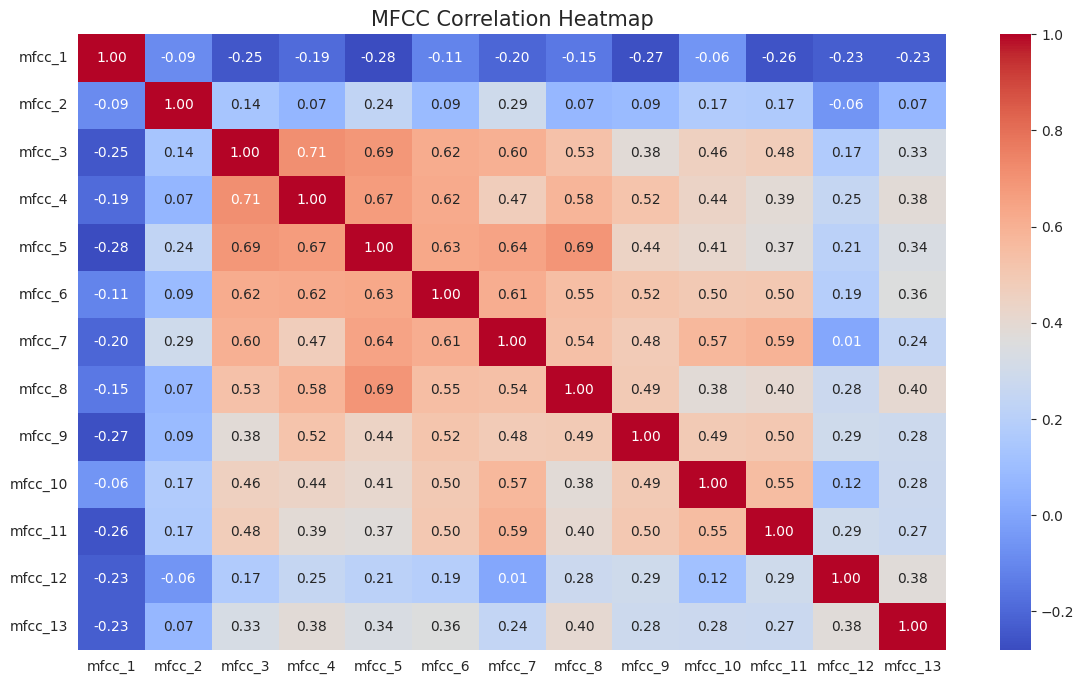

In [8]:
## Cell 9: MFCC Feature Heatmap

mfcc_columns = [
    f"mfcc_{i}"
    for i in range(1,14)
]

plt.figure(figsize=(14,8))

sns.heatmap(
    feature_df[mfcc_columns].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title(
    "MFCC Correlation Heatmap",
    fontsize=15
)

plt.show()


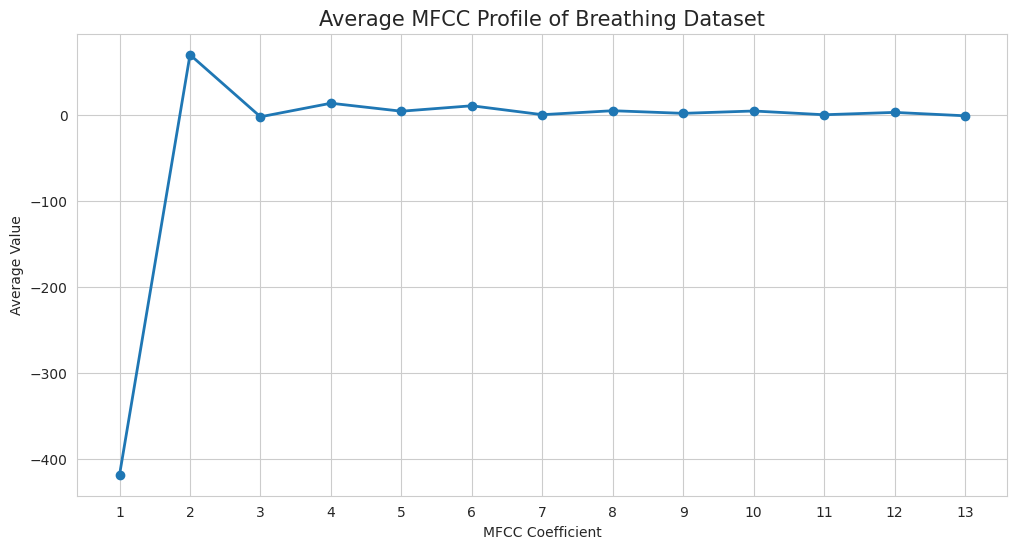

In [9]:
## Cell 10: Average MFCC Profile

mfcc_means = [
    feature_df[f"mfcc_{i}"].mean()
    for i in range(1,14)
]

plt.figure(figsize=(12,6))

plt.plot(
    range(1,14),
    mfcc_means,
    marker="o",
    linewidth=2
)

plt.title(
    "Average MFCC Profile of Breathing Dataset",
    fontsize=15
)

plt.xlabel("MFCC Coefficient")
plt.ylabel("Average Value")

plt.xticks(range(1,14))

plt.grid(True)

plt.show()


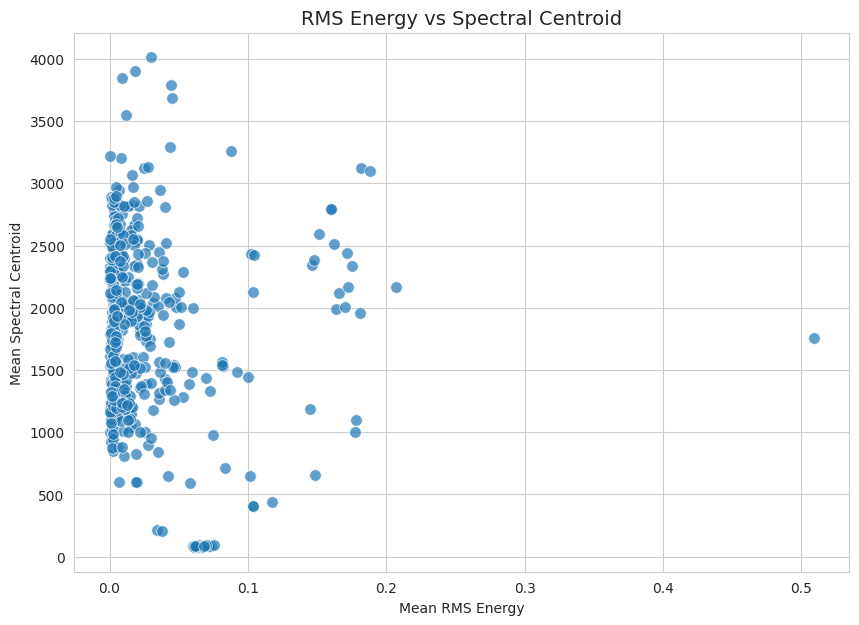

In [10]:
## Cell 11: RMS vs Spectral Centroid

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=feature_df,
    x="rms_mean",
    y="spectral_centroid_mean",
    s=70,
    alpha=0.7
)

plt.title(
    "RMS Energy vs Spectral Centroid",
    fontsize=14
)

plt.xlabel("Mean RMS Energy")
plt.ylabel("Mean Spectral Centroid")

plt.show()


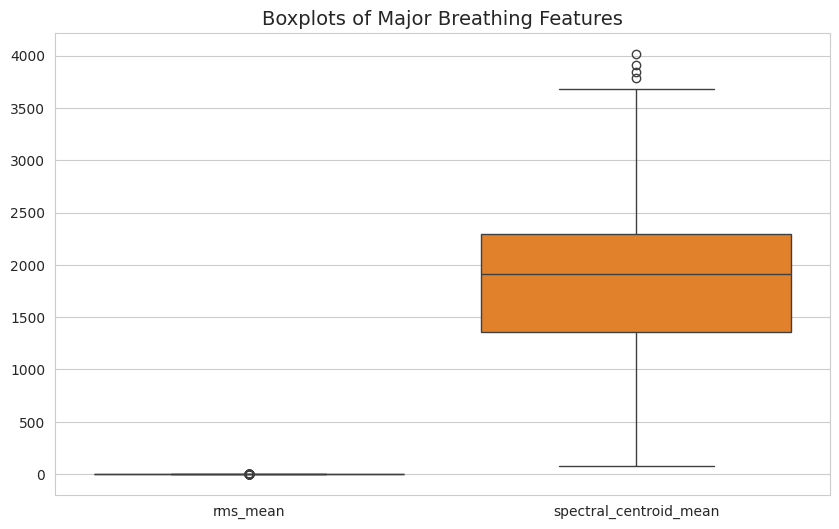

In [11]:

## Cell 12: Boxplots of Major Features


major_features = feature_df[
    ["rms_mean",
     "spectral_centroid_mean"]
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=major_features
)

plt.title(
    "Boxplots of Major Breathing Features",
    fontsize=14
)

plt.show()



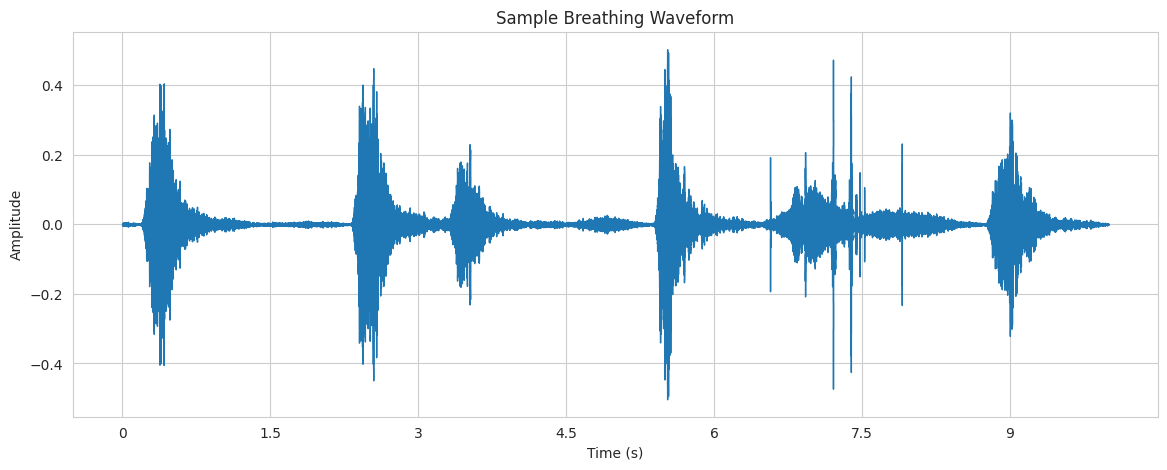

In [12]:
## Cell 13: Visualize a Sample Breathing Signal


sample_file = audio_files[0]

y, sr = librosa.load(
    sample_file,
    sr=None
)

plt.figure(figsize=(14,5))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(
    "Sample Breathing Waveform"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()



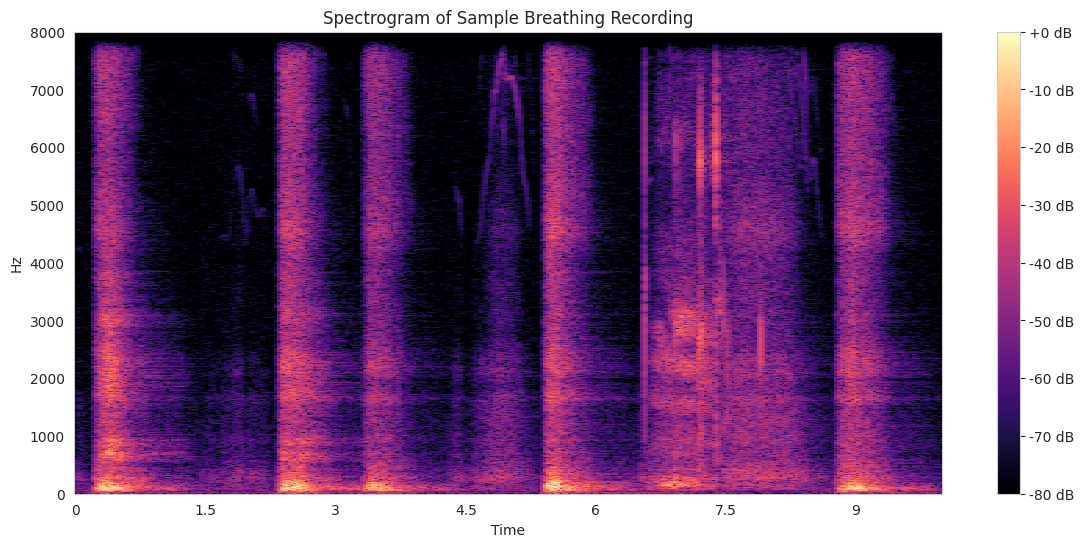

In [13]:
## Cell 14: Sample Spectrogram


D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

plt.figure(figsize=(14,6))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    "Spectrogram of Sample Breathing Recording"
)

plt.show()
